functions to use

In [5]:
def data_info(data):

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
    duplicates=data.duplicated().sum()


    info_df=pd.DataFrame({'Name':Names,
                        'Data_Type':data_types,
                        'Top_10_Unique_Values':top_10_unique_values,
                        'Nunique_Values':nunique_values,
                        'Nulls':nulls,
                        'Percent_of_Nulls':percent_of_Nulls,
                        'Duplicates':duplicates})
    return info_df

importing libraries

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
import joblib
import category_encoders as ce
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

 loading data

In [7]:
df = pd.read_csv("job_salary_prediction_dataset.csv")

 data overview



In [8]:
df.shape

(250000, 10)

* data is pretty big


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


* no nulls in the data
* data is mostly object datatype

In [10]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


* outliers in the certifications and salary columns

In [11]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,job_title,object,"[Backend Developer, Cybersecurity Analyst, Pro...",12,0,0.0,0
1,experience_years,int64,"[14, 18, 15, 1, 4, 7, 20, 2, 12, 16]",21,0,0.0,0
2,education_level,object,"[Master, High School, Bachelor, PhD, Diploma]",5,0,0.0,0
3,skills_count,int64,"[14, 9, 8, 1, 3, 17, 16, 5, 6, 10]",19,0,0.0,0
4,industry,object,"[Finance, Consulting, Media, Manufacturing, Te...",10,0,0.0,0
5,company_size,object,"[Large, Small, Medium, Enterprise, Startup]",5,0,0.0,0
6,location,object,"[Australia, Canada, Sweden, Remote, Singapore,...",10,0,0.0,0
7,remote_work,object,"[No, Hybrid, Yes]",3,0,0.0,0
8,certifications,int64,"[0, 3, 2, 1, 4, 5]",6,0,0.0,0
9,salary,int64,"[140468, 156899, 131287, 164406, 126339, 14483...",118956,0,0.0,0


* location has 10 diffrant unique values (remote included)

* hyprid remote work (encoding status => (label encoder, one hot encoder))

## dividing columns to work on them proberly


* num_cols => columns that has numerical values that will be treated as numerical
* bin_cols => columns that has the values yes or no included in there unique values
* ordinal_cols => columns that has values that can be organized in order

* nominal_cols => columns that has values that has nothing to do with each other

In [12]:
num_cols = ['salary']
ordinal_cols = ['certifications', 'skills_count', 'experience_years', 'education_level', 'company_size']
nominal_cols = ['job_title', 'industry', 'location']
bin_cols = ['remote_work']

###type casting the columns

In [13]:
df[nominal_cols] = df[nominal_cols].astype(object)
df[ordinal_cols] = df[ordinal_cols].astype(object)
df[bin_cols] = df[bin_cols].astype(object)

# visualization


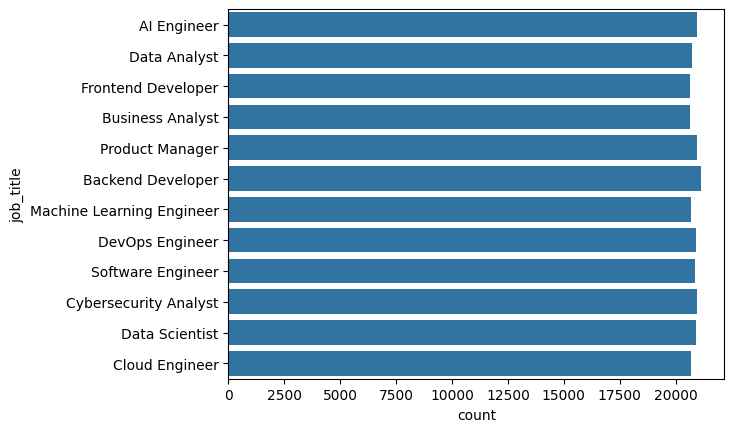

In [14]:
sns.countplot(df['job_title'])
plt.show()

* no information gain except than that the column is balanced

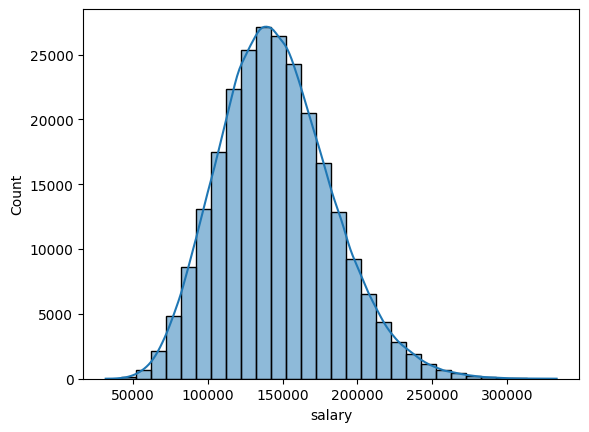

In [15]:
sns.histplot(df['salary'], kde = True, bins = 30 )
plt.show()

* the target column is normally distrputed


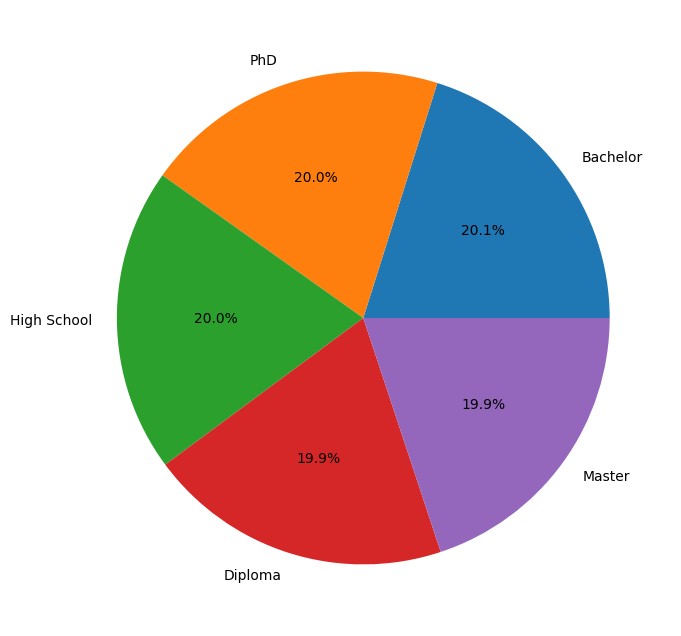

In [16]:
plt.figure(figsize = (10,8))
plt.pie(df['education_level'].value_counts(), labels = df['education_level'].unique(), autopct = '%1.1f%%')
plt.show()

* this column is also balanced

* the data is likely to have low correlation with the target column

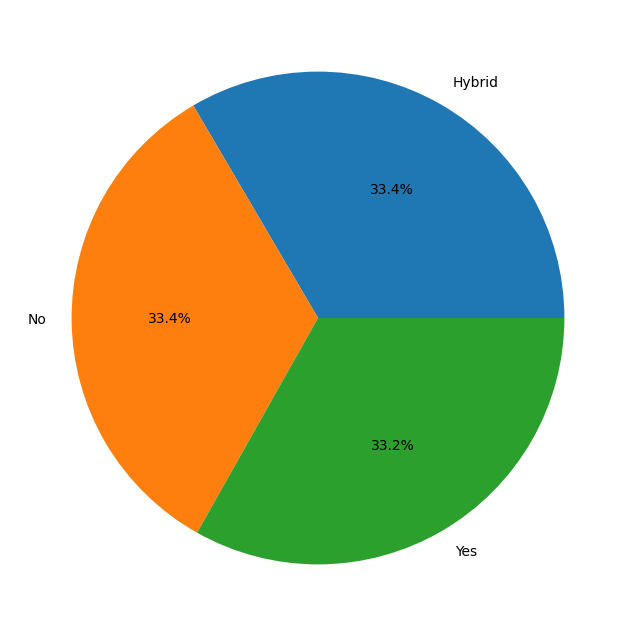

In [17]:
for col in bin_cols:
  plt.figure(figsize = (10,8))
  plt.pie(df[col].value_counts(), labels=df[col].unique(), autopct='%1.1f%%')
  plt.show()

* the data is not biased and balanced in vlaue count

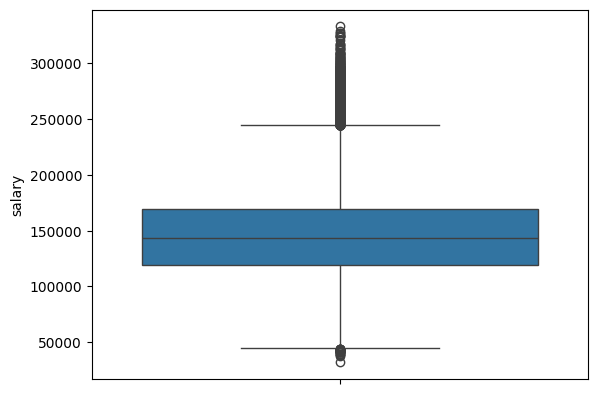

In [18]:
sns.boxplot(df['salary'])
plt.show()

* outliers in the salary column

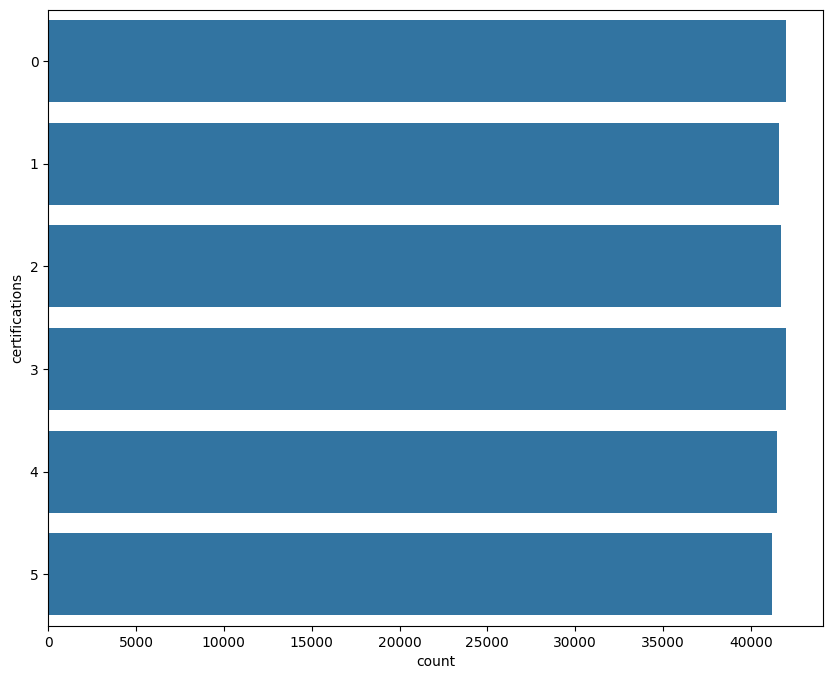

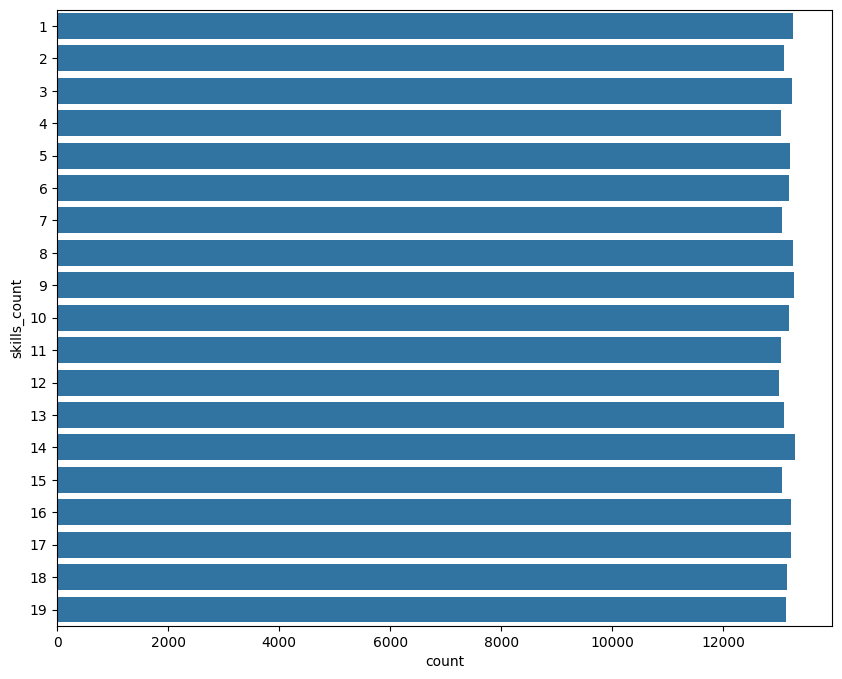

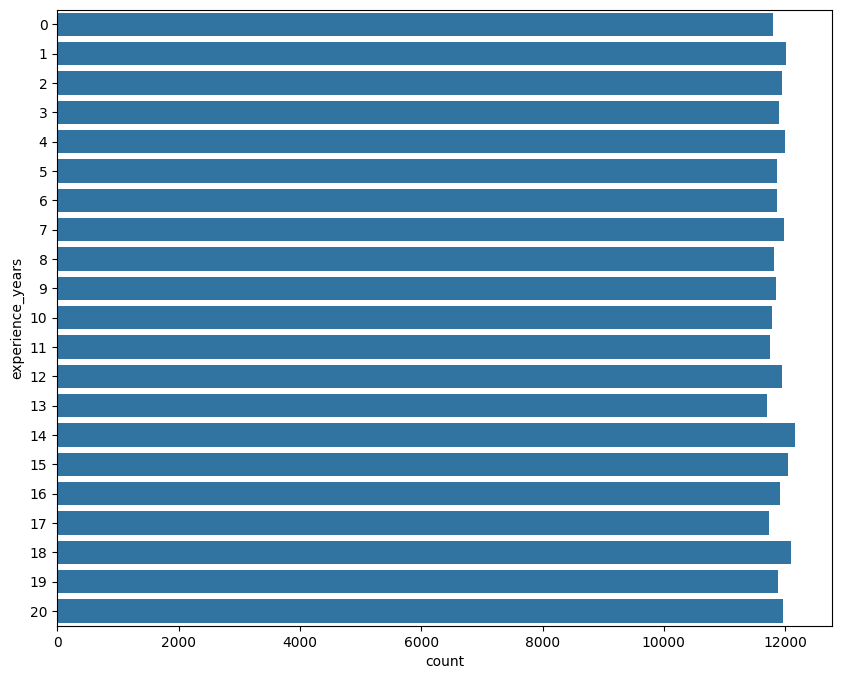

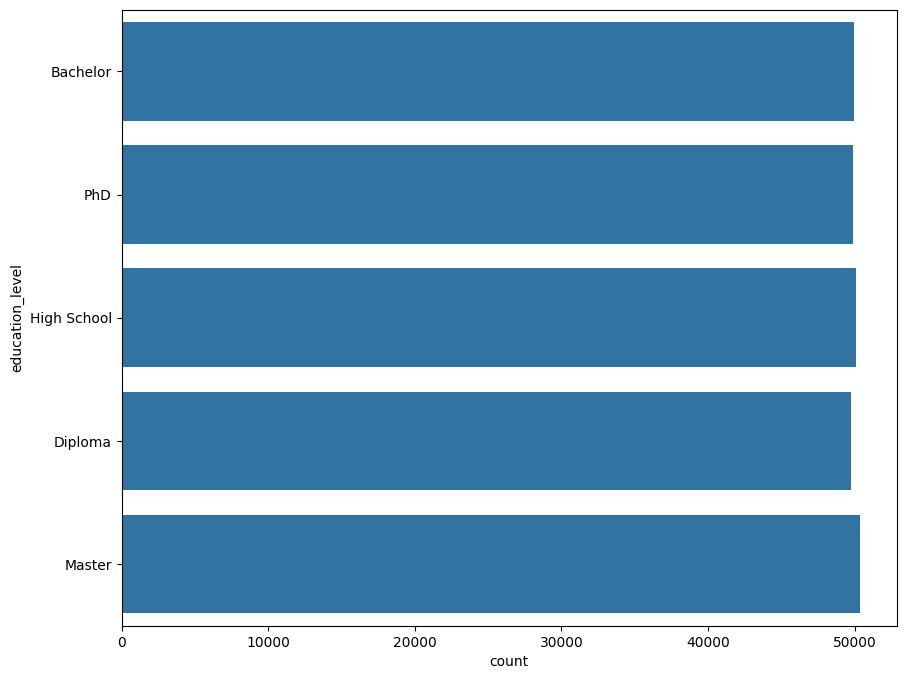

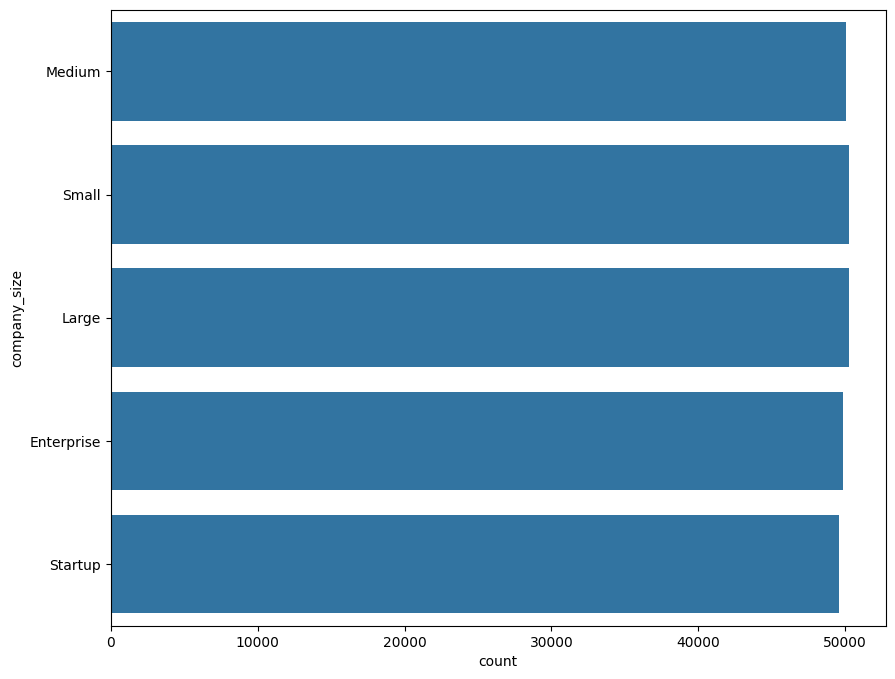

In [19]:
for col in ordinal_cols:
  plt.figure(figsize = (10,8))
  sns.countplot(y = df[col])
  plt.show()

* all the data value count are almost like each other (susbected low data correlation)

# Preprocessing (Duplicates, Outliers)

In [20]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,job_title,object,"[Backend Developer, Cybersecurity Analyst, Pro...",12,0,0.0,0
1,experience_years,object,"[14, 18, 15, 1, 4, 7, 20, 2, 12, 16]",21,0,0.0,0
2,education_level,object,"[Master, High School, Bachelor, PhD, Diploma]",5,0,0.0,0
3,skills_count,object,"[14, 9, 8, 1, 3, 17, 16, 5, 6, 10]",19,0,0.0,0
4,industry,object,"[Finance, Consulting, Media, Manufacturing, Te...",10,0,0.0,0
5,company_size,object,"[Large, Small, Medium, Enterprise, Startup]",5,0,0.0,0
6,location,object,"[Australia, Canada, Sweden, Remote, Singapore,...",10,0,0.0,0
7,remote_work,object,"[No, Hybrid, Yes]",3,0,0.0,0
8,certifications,object,"[0, 3, 2, 1, 4, 5]",6,0,0.0,0
9,salary,int64,"[140468, 156899, 131287, 164406, 126339, 14483...",118956,0,0.0,0


drop duplicates

In [21]:
duplicates=df.duplicated().sum()
print(duplicates)

0


In [22]:
df.drop_duplicates(inplace=True)

* No duplicates in the data

handle outliers

handling certifications and salary

In [23]:
def handle_Numerical_outliers(data):

    num_cols =['certifications', 'salary']

    for col in num_cols:

        Q1=data[col].quantile(0.25)
        Q3=data[col].quantile(0.75)
        IQR=Q3-Q1

        lower_bound=Q1-(1.5*IQR)
        upper_bound=Q3+(1.5*IQR)

        data[col]=np.where(data[col]<lower_bound,lower_bound,data[col])
        data[col]=np.where(data[col]>upper_bound,upper_bound,data[col])
    return data # Return the modified DataFrame

df = handle_Numerical_outliers(df) # Apply the outlier handling function

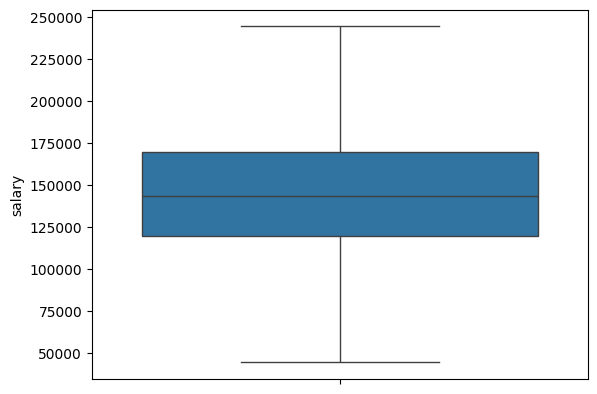

In [24]:
sns.boxplot(df['salary'])
plt.show()

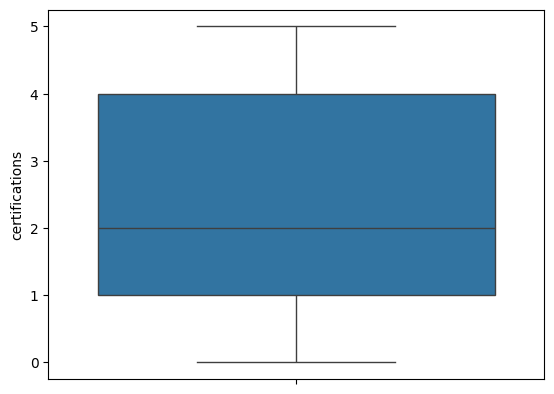

In [25]:
sns.boxplot(df['certifications'])
plt.show()

# Feature Engineering

* Job Role Grouping

In [26]:
def group_job_titles(title):
    title = title.lower()
    if 'data scientist' in title or 'nlp' in title or 'research' in title:
        return 'Data Science'
    elif 'engineer' in title or 'infrastructure' in title:
        return 'Engineering'
    elif 'analyst' in title or 'analytics' in title:
        return 'Analyst'
    elif 'manager' in title or 'head' in title or 'director' in title:
        return 'Management'
    else:
        return 'Other'
df['Job_Category'] = df['job_title'].apply(group_job_titles)

* Seniority Extraction

In [27]:
df['Is_Lead_Role'] = df['job_title'].str.contains('Lead|Principal|Manager|Head|Director', case=False).astype(int)

In [28]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,job_title,object,"[Backend Developer, Cybersecurity Analyst, Pro...",12,0,0.0,1
1,experience_years,object,"[14, 18, 15, 1, 4, 7, 20, 2, 12, 16]",21,0,0.0,1
2,education_level,object,"[Master, High School, Bachelor, PhD, Diploma]",5,0,0.0,1
3,skills_count,object,"[14, 9, 8, 1, 3, 17, 16, 5, 6, 10]",19,0,0.0,1
4,industry,object,"[Finance, Consulting, Media, Manufacturing, Te...",10,0,0.0,1
5,company_size,object,"[Large, Small, Medium, Enterprise, Startup]",5,0,0.0,1
6,location,object,"[Australia, Canada, Sweden, Remote, Singapore,...",10,0,0.0,1
7,remote_work,object,"[No, Hybrid, Yes]",3,0,0.0,1
8,certifications,object,"[0, 3, 2, 1, 4, 5]",6,0,0.0,1
9,salary,float64,"[244693.0, 44157.0, 140468.0, 156899.0, 131287...",116698,0,0.0,1


## Encoding

In [29]:
edu_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']
size_order = ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']
remote_order = ['No', 'Hybrid', 'Yes']

ord_enc = OrdinalEncoder(categories=[edu_order, size_order, remote_order])
ord_cols = ['education_level', 'company_size', 'remote_work']

df[ord_cols] = ord_enc.fit_transform(df[ord_cols])

nominal_cols = ['Job_Category', 'industry', 'location', 'job_title']
ohe_enc = ce.OneHotEncoder(cols=nominal_cols, use_cat_names=True)
df_encoded = ohe_enc.fit_transform(df)

joblib.dump(ord_enc, 'ordinal_encoder.pkl')
joblib.dump(ohe_enc, 'ohe_encoder.pkl')

['ohe_encoder.pkl']

In [30]:
data_info(df_encoded)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,job_title_AI Engineer,int64,"[0, 1]",2,0,0.0,1
1,job_title_Data Analyst,int64,"[0, 1]",2,0,0.0,1
2,job_title_Frontend Developer,int64,"[0, 1]",2,0,0.0,1
3,job_title_Business Analyst,int64,"[0, 1]",2,0,0.0,1
4,job_title_Product Manager,int64,"[0, 1]",2,0,0.0,1
5,job_title_Backend Developer,int64,"[0, 1]",2,0,0.0,1
6,job_title_Machine Learning Engineer,int64,"[0, 1]",2,0,0.0,1
7,job_title_DevOps Engineer,int64,"[0, 1]",2,0,0.0,1
8,job_title_Software Engineer,int64,"[0, 1]",2,0,0.0,1
9,job_title_Cybersecurity Analyst,int64,"[0, 1]",2,0,0.0,1


In [31]:
cols_to_fix = ['experience_years', 'skills_count', 'certifications']
for col in cols_to_fix:
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce')

## Data Splitting

In [32]:
X = df_encoded.drop(columns=['salary'], errors='ignore')
y = df_encoded['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Data Scaling

In [33]:
scaler = StandardScaler()

num_cols = ['experience_years', 'skills_count', 'certifications', 'education_level', 'company_size', 'remote_work']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [34]:
X_train

,job_title_AI Engineer,job_title_Data Analyst,job_title_Frontend Developer,job_title_Business Analyst,job_title_Product Manager,job_title_Backend Developer,job_title_Machine Learning Engineer,job_title_DevOps Engineer,job_title_Software Engineer,job_title_Cybersecurity Analyst,...,location_Germany,location_UK,remote_work,certifications,Job_Category_Engineering,Job_Category_Analyst,Job_Category_Other,Job_Category_Management,Job_Category_Data Science,Is_Lead_Role
192448,0,0,0,0,0,0,0,1,0,0,...,0,0,-1.220245,-0.289854,1,0,0,0,0,0
139604,1,0,0,0,0,0,0,0,0,0,...,0,0,1.231636,1.465966,1,0,0,0,0,0
140914,1,0,0,0,0,0,0,0,0,0,...,0,0,-1.220245,1.465966,1,0,0,0,0,0
80088,1,0,0,0,0,0,0,0,0,0,...,0,0,-1.220245,0.295419,1,0,0,0,0,0
72918,0,0,0,0,0,1,0,0,0,0,...,0,0,0.005695,0.880692,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,0,0,0,0,0,0,1,0,0,0,...,0,0,-1.220245,-1.460401,1,0,0,0,0,0
103694,0,0,0,0,0,0,0,0,0,1,...,0,0,1.231636,0.880692,0,1,0,0,0,0
131932,0,0,1,0,0,0,0,0,0,0,...,0,0,0.005695,-1.460401,0,0,1,0,0,0
146867,0,1,0,0,0,0,0,0,0,0,...,0,0,-1.220245,-0.289854,0,1,0,0,0,0


In [44]:
print(list(X_train.columns))

['job_title_AI Engineer', 'job_title_Data Analyst', 'job_title_Frontend Developer', 'job_title_Business Analyst', 'job_title_Product Manager', 'job_title_Backend Developer', 'job_title_Machine Learning Engineer', 'job_title_DevOps Engineer', 'job_title_Software Engineer', 'job_title_Cybersecurity Analyst', 'job_title_Data Scientist', 'job_title_Cloud Engineer', 'experience_years', 'education_level', 'skills_count', 'industry_Healthcare', 'industry_Telecom', 'industry_Media', 'industry_Retail', 'industry_Manufacturing', 'industry_Education', 'industry_Finance', 'industry_Technology', 'industry_Consulting', 'industry_Government', 'company_size', 'location_India', 'location_Australia', 'location_Singapore', 'location_Canada', 'location_Sweden', 'location_USA', 'location_Netherlands', 'location_Remote', 'location_Germany', 'location_UK', 'remote_work', 'certifications', 'Job_Category_Engineering', 'Job_Category_Analyst', 'Job_Category_Other', 'Job_Category_Management', 'Job_Category_Data S

## Modeling

In [35]:
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

xgb_grid = GridSearchCV(XGBRegressor(), xgb_params, cv=3, scoring='r2', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"XGBoost Best Score: {xgb_grid.best_score_}")
print(f"XGBoost Best Params: {xgb_grid.best_params_}")

XGBoost Best Score: 0.9789921456180771
XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [36]:
print(f"XGBoost Test Score: {xgb_grid.score(X_test, y_test):.4f}")

XGBoost Test Score: 0.9793


In [37]:
rf_params = {
    'n_estimators': [100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestRegressor(), rf_params, cv=3, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"RF Best Score: {rf_grid.best_score_}")
print(f"RF Best Params: {rf_grid.best_params_}")

RF Best Score: 0.9685653803477615
RF Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


In [38]:
print(f"RF Test Score: {rf_grid.score(X_test, y_test):.4f}")

RF Test Score: 0.9706


In [39]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print(f"Linear Regression R2 Score: {lr_model.score(X_train, y_train):.4f}")
print(f"Linear Regression R2 Score: {lr_model.score(X_test, y_test):.4f}")

Linear Regression R2 Score: 0.9565
Linear Regression R2 Score: 0.9558


In [40]:
knn_params = {
    'n_neighbors': [3, 5],
    'weights': ['distance']
}

knn_grid = GridSearchCV(KNeighborsRegressor(), knn_params, cv=3, scoring='r2', n_jobs=-1)
knn_grid.fit(X_train, y_train)

print(f"KNN Best Score: {knn_grid.best_score_:.4f}")
print(f"KNN Best Params: {knn_grid.best_params_}")
print(f"KNN Test Score: {knn_grid.score(X_test, y_test):.4f}")

KNN Best Score: 0.8901
KNN Best Params: {'n_neighbors': 5, 'weights': 'distance'}
KNN Test Score: 0.9049


In [41]:
# Saving the best model (XGBoost in this case) using joblib
joblib.dump(xgb_grid, 'xgb_model.pkl')

['xgb_model.pkl']